In [926]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import matplotlib.pyplot as plt

# 3 Movement Directions

## LP Solution

### Input Data

In [927]:
n = 5
I = range(n)

# Dummy monotone input points A and B
a_x = np.zeros(n)
a_y = np.zeros(n)

# Shifted monotone targets
b_x = a_x + np.random.randint(1, 10, size=n)
b_y = a_y + np.random.randint(1, 10, size=n)

# Create model
model = gp.Model("Monotone_Movement_LP")

### Decision Variables

In [928]:
k = model.addVars(I, lb=0, name="k")
l = model.addVars(I, lb=0, name="l")
m = model.addVars(I, lb=0, name="m")

K_max = model.addVar(lb=0, name="K_max")
L_max = model.addVar(lb=0, name="L_max")
M_max = model.addVar(lb=0, name="M_max")

### Position Constraints

In [929]:
for i in I:
    model.addConstr(
        b_x[i] - a_x[i] - k[i] - l[i] == 0,
        name=f"x_position_{i}"
    )

    model.addConstr(
        b_y[i] - a_y[i] - m[i] - l[i] == 0,
        name=f"y_position_{i}"
    )

### Monotonicity Constraints

In [930]:
for i in I:
    model.addConstr(k[i] >= 0, name=f"k_nonneg_{i}")
    model.addConstr(l[i] >= 0, name=f"l_nonneg_{i}")
    model.addConstr(m[i] >= 0, name=f"m_nonneg_{i}")

### Determining Maximal Movements

In [931]:
for i in I:
    model.addConstr(K_max >= k[i], name=f"K_max_{i}")
    model.addConstr(L_max >= l[i], name=f"L_max_{i}")
    model.addConstr(M_max >= m[i], name=f"M_max_{i}")

### Optimization Objective

In [932]:
model.setObjective(
    K_max + 1.414 * L_max + M_max,
    GRB.MINIMIZE
)

### Solving and Inspection

In [933]:
model.optimize()

if model.status == GRB.OPTIMAL:
    print("Optimal objective value:", model.objVal)
    print("K_max:", K_max.x)
    print("L_max:", L_max.x)
    print("M_max:", M_max.x)

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.3.0 25D125)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 40 rows, 18 columns and 65 nonzeros (Min)
Model fingerprint: 0x2d2600f3
Model has 3 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+00, 7e+00]

Presolve removed 35 rows and 12 columns
Presolve time: 0.00s
Presolved: 5 rows, 6 columns, 15 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    9.8280000e+00   2.000000e+00   0.000000e+00      0s
       2    1.1828000e+01   0.000000e+00   0.000000e+00      0s

Solved in 2 iterations and 0.00 seconds (0.00 work units)
Optimal objective  1.182800000e+01
Optimal objective value: 11.828
K_max: 5.0
L_max: 2.0
M_max: 4.0


In [934]:
# Print per-point decomposition (ensure model is solved)
if model.status != GRB.OPTIMAL:
    model.optimize()

print("Per-point decomposition (k, l, m) and consistency checks:\n")
for i in I:
    kv = k[i].x
    lv = l[i].x
    mv = m[i].x
    dx = int(b_x[i] - a_x[i])
    dy = int(b_y[i] - a_y[i])
    print(
        f"Point {i}: ({a_x[i]}, {a_y[i]}) -> ({b_x[i]}, {b_y[i]}) | "
        f"k={kv:.6f}, l={lv:.6f}, m={mv:.6f} | "
        f"k+l={kv+lv:.6f} (dx={dx}), l+m={lv+mv:.6f} (dy={dy})"
    )

Per-point decomposition (k, l, m) and consistency checks:

Point 0: (0.0, 0.0) -> (5.0, 4.0) | k=3.000000, l=2.000000, m=2.000000 | k+l=5.000000 (dx=5), l+m=4.000000 (dy=4)
Point 1: (0.0, 0.0) -> (4.0, 3.0) | k=4.000000, l=0.000000, m=3.000000 | k+l=4.000000 (dx=4), l+m=3.000000 (dy=3)
Point 2: (0.0, 0.0) -> (7.0, 2.0) | k=5.000000, l=2.000000, m=0.000000 | k+l=7.000000 (dx=7), l+m=2.000000 (dy=2)
Point 3: (0.0, 0.0) -> (5.0, 4.0) | k=5.000000, l=0.000000, m=4.000000 | k+l=5.000000 (dx=5), l+m=4.000000 (dy=4)
Point 4: (0.0, 0.0) -> (7.0, 6.0) | k=5.000000, l=2.000000, m=4.000000 | k+l=7.000000 (dx=7), l+m=6.000000 (dy=6)


### Figure

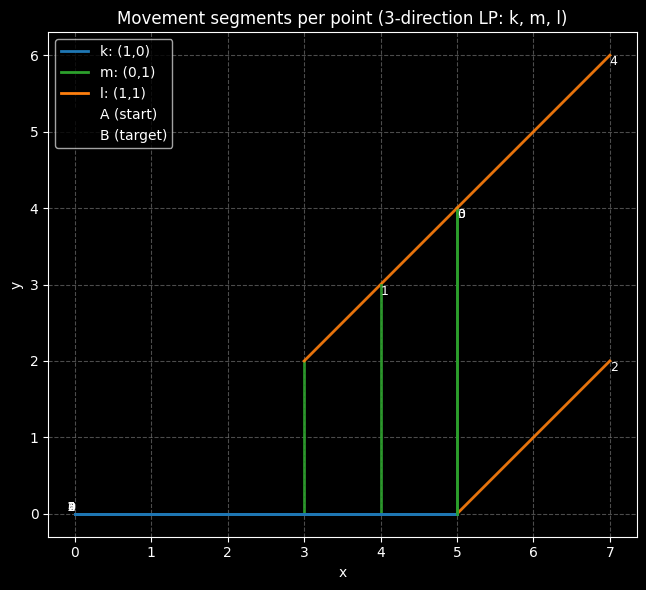

In [935]:
# Recompute the original 3-direction LP solution (k: (1,0), l: (1,1), m: (0,1))
model_3 = gp.Model("Monotone_Movement_LP_3dir_recompute")
model_3.Params.OutputFlag = 0

n_pts = len(a_x)
I_pts = range(n_pts)

k3 = model_3.addVars(I_pts, lb=0.0, name="k")
l3 = model_3.addVars(I_pts, lb=0.0, name="l")
m3 = model_3.addVars(I_pts, lb=0.0, name="m")

K_max3 = model_3.addVar(lb=0.0, name="K_max")
L_max3 = model_3.addVar(lb=0.0, name="L_max")
M_max3 = model_3.addVar(lb=0.0, name="M_max")

for i in I_pts:
    model_3.addConstr(b_x[i] - a_x[i] - k3[i] - l3[i] == 0.0, name=f"x_position_{i}")
    model_3.addConstr(b_y[i] - a_y[i] - m3[i] - l3[i] == 0.0, name=f"y_position_{i}")

for i in I_pts:
    model_3.addConstr(K_max3 >= k3[i], name=f"K_max_{i}")
    model_3.addConstr(L_max3 >= l3[i], name=f"L_max_{i}")
    model_3.addConstr(M_max3 >= m3[i], name=f"M_max_{i}")

model_3.setObjective(K_max3 + 1.414 * L_max3 + M_max3, GRB.MINIMIZE)
model_3.optimize()

if model_3.status != GRB.OPTIMAL:
    raise RuntimeError(f"3-direction LP did not solve to optimality (status={model_3.status}).")

k_vals = [float(k3[i].X) for i in I_pts]
l_vals = [float(l3[i].X) for i in I_pts]
m_vals = [float(m3[i].X) for i in I_pts]

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(a_x, a_y, c="black", s=50, marker="o", label="A (start)")
ax.scatter(b_x, b_y, c="black", s=60, marker="x", label="B (target)")

colors = {"k": "#1f77b4", "l": "#ff7f0e", "m": "#2ca02c"}

for i in I_pts:
    x0, y0 = float(a_x[i]), float(a_y[i])

    # Segment 1: k (horizontal)
    x1, y1 = x0 + k_vals[i], y0
    ax.plot([x0, x1], [y0, y1], color=colors["k"], linewidth=2, alpha=0.9)

    # Segment 2: m (vertical)
    x2, y2 = x1, y1 + m_vals[i]
    ax.plot([x1, x2], [y1, y2], color=colors["m"], linewidth=2, alpha=0.9)

    # Segment 3: l (diagonal 45 degrees)
    x3, y3 = x2 + l_vals[i], y2 + l_vals[i]
    ax.plot([x2, x3], [y2, y3], color=colors["l"], linewidth=2, alpha=0.9)

    ax.text(x0, y0, f"{i}", fontsize=9, ha="right", va="bottom")
    ax.text(float(b_x[i]), float(b_y[i]), f"{i}", fontsize=9, ha="left", va="top")

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Movement segments per point (3-direction LP: k, m, l)")
ax.grid(True, linestyle="--", alpha=0.3)

handles = [
    plt.Line2D([0], [0], color=colors["k"], lw=2, label="k: (1,0)"),
    plt.Line2D([0], [0], color=colors["m"], lw=2, label="m: (0,1)"),
    plt.Line2D([0], [0], color=colors["l"], lw=2, label="l: (1,1)"),
    plt.Line2D([0], [0], marker="o", color="black", lw=0, markersize=7, label="A (start)"),
    plt.Line2D([0], [0], marker="x", color="black", lw=0, markersize=7, label="B (target)"),
]
ax.legend(handles=handles, loc="best")

plt.tight_layout()
plt.show()


### Figure including overlay of F

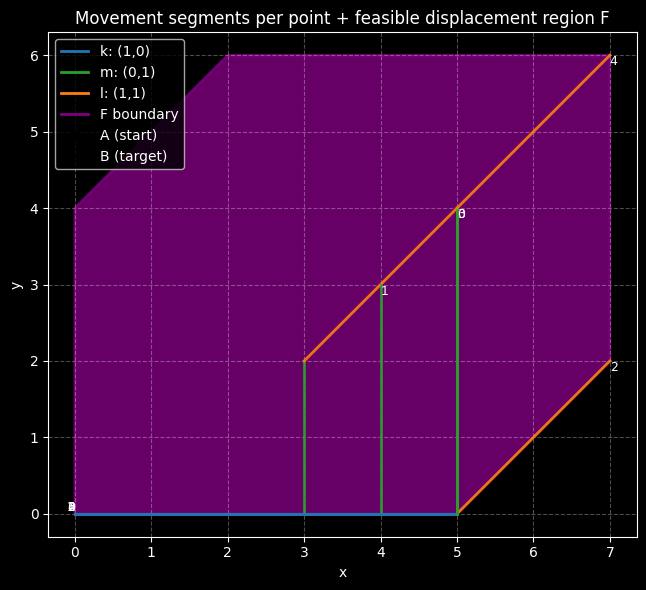

In [936]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

K = float(K_max3.X)
L = float(L_max3.X)
M = float(M_max3.X)

# Algoritme gestolen van: https://en.wikibooks.org/wiki/Algorithm_Implementation/Geometry/Convex_hull/Monotone_chain
def convex_hull(points):
    # points: list of (x,y)
    pts = sorted(set(points))
    if len(pts) <= 1:
        return pts

    def cross(o, a, b):
        return (a[0]-o[0])*(b[1]-o[1]) - (a[1]-o[1])*(b[0]-o[0])

    lower = []
    for p in pts:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(p)

    upper = []
    for p in reversed(pts):
        while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(p)

    return lower[:-1] + upper[:-1]


# F plotten
corners_Q = [(a, b, c) for a in (0.0, K) for b in (0.0, L) for c in (0.0, M)]
points_F = [(a + b, b + c) for (a, b, c) in corners_Q]

hull_F = convex_hull(points_F)

# Zelfde plot code -- plus overlay van F
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(a_x, a_y, c="black", s=50, marker="o", label="A (start)")
ax.scatter(b_x, b_y, c="black", s=60, marker="x", label="B (target)")

colors = {"k": "#1f77b4", "l": "#ff7f0e", "m": "#2ca02c"}

for i in I_pts:
    x0, y0 = float(a_x[i]), float(a_y[i])

    # Segment 1: k (horizontal)
    x1, y1 = x0 + k_vals[i], y0
    ax.plot([x0, x1], [y0, y1], color=colors["k"], linewidth=2, alpha=0.9)

    # Segment 2: m (vertical)
    x2, y2 = x1, y1 + m_vals[i]
    ax.plot([x1, x2], [y1, y2], color=colors["m"], linewidth=2, alpha=0.9)

    # Segment 3: l (diagonal 45 degrees)
    x3, y3 = x2 + l_vals[i], y2 + l_vals[i]
    ax.plot([x2, x3], [y2, y3], color=colors["l"], linewidth=2, alpha=0.9)

    ax.text(x0, y0, f"{i}", fontsize=9, ha="right", va="bottom")
    ax.text(float(b_x[i]), float(b_y[i]), f"{i}", fontsize=9, ha="left", va="top")

# F Overlay
poly_F = Polygon(
    hull_F,
    closed=True,
    fill=True,
    alpha=0.8,
    edgecolor="purple",
    linewidth=2.0,
    facecolor="purple",
    label=fr"Feasible region $F$ (K={K:.3g}, L={L:.3g}, M={M:.3g})"
)
ax.add_patch(poly_F)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Movement segments per point + feasible displacement region F")
ax.grid(True, linestyle="--", alpha=0.3)

handles = [
    plt.Line2D([0], [0], color=colors["k"], lw=2, label="k: (1,0)"),
    plt.Line2D([0], [0], color=colors["m"], lw=2, label="m: (0,1)"),
    plt.Line2D([0], [0], color=colors["l"], lw=2, label="l: (1,1)"),
    plt.Line2D([0], [0], color="purple", lw=2, label="F boundary"),
    plt.Line2D([0], [0], marker="o", color="black", lw=0, markersize=7, label="A (start)"),
    plt.Line2D([0], [0], marker="x", color="black", lw=0, markersize=7, label="B (target)"),
]
ax.legend(handles=handles, loc="best")

plt.tight_layout()
plt.show()

## Exact Algorithm

### Algorithm

In [937]:
def solve_restricted_2d(a_x, a_y, b_x, b_y, eps=1e-12):
    dx = b_x - a_x
    dy = b_y - a_y

    if np.any(dx < -eps) or np.any(dy < -eps):
        raise ValueError("Displacements must be nonnegative (dx, dy >= 0).")

    Xmax = float(np.max(dx))
    Ymax = float(np.max(dy))
    Dxy  = float(np.max(dx - dy))  # max(x - y)
    Dyx  = float(np.max(dy - dx))  # max(y - x)

    # Candidate L values (breakpoints of the piecewise-linear objective)
    candidates = [
        0.0,
        Xmax,
        Ymax,
        Xmax - Dxy,
        Ymax - Dyx
    ]

    # Keep only nonnegative unique values
    candidates = sorted({max(0.0, float(L)) for L in candidates})

    def K_of(L):
        return max(0.0, Dxy, Xmax - L)

    def M_of(L):
        return max(0.0, Dyx, Ymax - L)

    best = None
    for L in candidates:
        K = K_of(L)
        M = M_of(L)
        obj = K + np.sqrt(2.0) * L + M
        if best is None or obj < best[0] - 1e-12:
            best = (obj, K, L, M)

    obj, K, L, M = best

    # Construct one feasible decomposition per point
    lower = np.maximum.reduce([np.zeros_like(dx), dx - K, dy - M])
    upper = np.minimum.reduce([np.full_like(dx, L), dx, dy])

    if np.any(lower > upper + 1e-9):
        raise RuntimeError("Unexpected infeasibility after optimization.")

    # Choose l_i at upper bound (any value in interval works)
    l = upper.copy()
    k = dx - l
    m = dy - l

    # Numerical cleanup
    k[np.abs(k) < 1e-12] = 0.0
    l[np.abs(l) < 1e-12] = 0.0
    m[np.abs(m) < 1e-12] = 0.0

    return K, L, M, obj, k, l, m, dx, dy

### Solution and Inspection

In [938]:
K, L, M, obj, k, l, m, dx, dy = solve_restricted_2d(a_x, a_y, b_x, b_y)

print("Displacements (dx, dy):")
for i in range(len(dx)):
    print(f"Point {i}: ({dx[i]:.6f}, {dy[i]:.6f})")

print("\nOptimal maxima:")
print(f"K_max = {K:.6f}")
print(f"L_max = {L:.6f}")
print(f"M_max = {M:.6f}")

print(f"\nFinal objective value: {obj:.6f}")

print("\nPer-point decomposition:")
for i in range(len(dx)):
    print(
        f"Point {i}: "
        f"k={k[i]:.6f}, "
        f"l={l[i]:.6f}, "
        f"m={m[i]:.6f} | "
        f"k+l={k[i]+l[i]:.6f} (dx={dx[i]:.6f}), "
        f"l+m={l[i]+m[i]:.6f} (dy={dy[i]:.6f})"
    )

Displacements (dx, dy):
Point 0: (5.000000, 4.000000)
Point 1: (4.000000, 3.000000)
Point 2: (7.000000, 2.000000)
Point 3: (5.000000, 4.000000)
Point 4: (7.000000, 6.000000)

Optimal maxima:
K_max = 5.000000
L_max = 2.000000
M_max = 4.000000

Final objective value: 11.828427

Per-point decomposition:
Point 0: k=3.000000, l=2.000000, m=2.000000 | k+l=5.000000 (dx=5.000000), l+m=4.000000 (dy=4.000000)
Point 1: k=2.000000, l=2.000000, m=1.000000 | k+l=4.000000 (dx=4.000000), l+m=3.000000 (dy=3.000000)
Point 2: k=5.000000, l=2.000000, m=0.000000 | k+l=7.000000 (dx=7.000000), l+m=2.000000 (dy=2.000000)
Point 3: k=3.000000, l=2.000000, m=2.000000 | k+l=5.000000 (dx=5.000000), l+m=4.000000 (dy=4.000000)
Point 4: k=5.000000, l=2.000000, m=4.000000 | k+l=7.000000 (dx=7.000000), l+m=6.000000 (dy=6.000000)


### Result comparison

In [939]:
print(f"\nFinal objective value non-LP: {obj:.6f}")
print("Final objective value LP:", model.objVal)


Final objective value non-LP: 11.828427
Final objective value LP: 11.828


# 5 Movement Directions

## LP Solution

### Decision Variables

In [940]:
k = model.addVars(I, lb=0, name="k") # (1,0)
l = model.addVars(I, lb=0, name="l") # (1,1)
m = model.addVars(I, lb=0, name="n") # (0,1)

g = model.addVars(I, lb=0, name="g") # 22.5 graden
h = model.addVars(I, lb=0, name="h") # 67.5 graden

K_max = model.addVar(lb=0, name="K_max")
L_max = model.addVar(lb=0, name="L_max")
M_max = model.addVar(lb=0, name="M_max")

G_max = model.addVar(lb=0, name="G_max")
H_max = model.addVar(lb=0, name="H_max")

### Position Constraints

In [941]:
for i in I:
    model.addConstr(
        b_x[i] - a_x[i] - k[i] - l[i] - g[i] - 0.414 * h[i] == 0,
        name=f"x_position_{i}"
    )

    model.addConstr(
        b_y[i] - a_y[i] - m[i] - l[i] - 0.414 * g[i] - h[i] == 0,
        name=f"y_position_{i}"
    )

### Monotonicity Constraints

In [942]:
for i in I:
    model.addConstr(k[i] >= 0, name=f"k_nonneg_{i}")
    model.addConstr(l[i] >= 0, name=f"l_nonneg_{i}")
    model.addConstr(m[i] >= 0, name=f"m_nonneg_{i}")
    model.addConstr(g[i] >= 0, name=f"g_nonneg_{i}")
    model.addConstr(h[i] >= 0, name=f"h_nonneg_{i}")

### Determining Maximal Movements

In [943]:
for i in I:
    model.addConstr(K_max >= k[i], name=f"K_max_{i}")
    model.addConstr(L_max >= l[i], name=f"L_max_{i}")
    model.addConstr(M_max >= m[i], name=f"M_max_{i}")
    model.addConstr(G_max >= g[i], name=f"G_max_{i}")
    model.addConstr(H_max >= h[i], name=f"H_max_{i}")

### Optimization Criteria

In [944]:
model.setObjective(
    K_max + 1.414 * L_max + M_max + 1.08 * G_max + 1.08 * H_max,
    GRB.MINIMIZE
)

### Solving and Inspection

In [945]:
model.optimize()

if model.status == GRB.OPTIMAL:
    print("Optimal objective value:", model.objVal)
    print("K_max:", K_max.x)
    print("L_max:", L_max.x)
    print("M_max:", M_max.x)
    print("G_max:", G_max.x)
    print("H_max:", H_max.x)

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.3.0 25D125)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 100 rows, 48 columns and 180 nonzeros (Min)
Model has 5 linear objective coefficients
Coefficient statistics:
  Matrix range     [4e-01, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+00, 7e+00]

LP warm-start: use basis

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   4.700000e+01   0.000000e+00      0s
      36    1.1386473e+01   0.000000e+00   0.000000e+00      0s

Solved in 36 iterations and 0.00 seconds (0.00 work units)
Optimal objective  1.138647343e+01
Optimal objective value: 11.38647342995169
K_max: 2.1690821256038646
L_max: 0.0
M_max: 4.0
G_max: 4.830917874396135
H_max: 0.0


In [946]:
# Print per-point decomposition (ensure model is solved)
if model.status != GRB.OPTIMAL:
    model.optimize()

print("Per-point decomposition (k, l, m, n):\n")
for i in I:
    kv = k[i].x
    lv = l[i].x
    mv = m[i].x
    gv = g[i].x
    hv = h[i].x
    dx = int(b_x[i] - a_x[i])
    dy = int(b_y[i] - a_y[i])
    print(
        f"Point {i}: ({a_x[i]}, {a_y[i]}) -> ({b_x[i]}, {b_y[i]}) | "
        f"k={kv:.6f}, l={lv:.6f}, m={mv:.6f}, g={gv:.6f}, h={hv:.6f} | "
    )

Per-point decomposition (k, l, m, n):

Point 0: (0.0, 0.0) -> (5.0, 4.0) | k=2.169082, l=0.000000, m=2.828000, g=2.830918, h=0.000000 | 
Point 1: (0.0, 0.0) -> (4.0, 3.0) | k=2.169082, l=0.000000, m=2.242000, g=1.830918, h=0.000000 | 
Point 2: (0.0, 0.0) -> (7.0, 2.0) | k=2.169082, l=0.000000, m=0.000000, g=4.830918, h=0.000000 | 
Point 3: (0.0, 0.0) -> (5.0, 4.0) | k=2.169082, l=0.000000, m=2.828000, g=2.830918, h=0.000000 | 
Point 4: (0.0, 0.0) -> (7.0, 6.0) | k=2.169082, l=0.000000, m=4.000000, g=4.830918, h=0.000000 | 


### Plotting

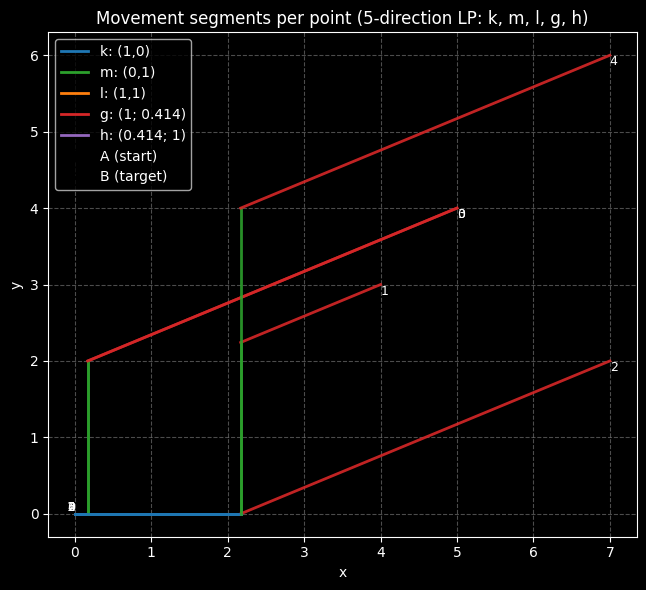

In [947]:
# Recompute the original 3-direction LP solution (k: (1,0), l: (1,1), m: (0,1))
model_5 = gp.Model("Monotone_Movement_LP_5dir_recompute")
model_5.Params.OutputFlag = 0

n_pts = len(a_x)
I_pts = range(n_pts)

k5 = model_5.addVars(I_pts, lb=0.0, name="k")
l5 = model_5.addVars(I_pts, lb=0.0, name="l")
m5 = model_5.addVars(I_pts, lb=0.0, name="m")
g5 = model_5.addVars(I_pts, lb=0.0, name="g")
h5 = model_5.addVars(I_pts, lb=0.0, name="h")

K_max5 = model_5.addVar(lb=0.0, name="K_max")
L_max5 = model_5.addVar(lb=0.0, name="L_max")
M_max5 = model_5.addVar(lb=0.0, name="M_max")
G_max5 = model_5.addVar(lb=0.0, name="G_max")
H_max5 = model_5.addVar(lb=0.0, name="H_max")

for i in I_pts:
    model_5.addConstr(b_x[i] - a_x[i] - k5[i] - l5[i] - g5[i] - 0.414 * h5[i] == 0.0, name=f"x_position_{i}")
    model_5.addConstr(b_y[i] - a_y[i] - m5[i] - l5[i] - 0.414 * g5[i] - h5[i] == 0.0, name=f"y_position_{i}")

for i in I_pts:
    model_5.addConstr(K_max5 >= k5[i], name=f"K_max_{i}")
    model_5.addConstr(L_max5 >= l5[i], name=f"L_max_{i}")
    model_5.addConstr(M_max5 >= m5[i], name=f"M_max_{i}")
    model_5.addConstr(G_max5 >= g5[i], name=f"G_max_{i}")
    model_5.addConstr(H_max5 >= h5[i], name=f"H_max_{i}")

model_5.setObjective(K_max5 + 1.414 * L_max5 + M_max5 + 1.08 * G_max5 + 1.08 * H_max5, GRB.MINIMIZE)
model_5.optimize()

if model_5.status != GRB.OPTIMAL:
    raise RuntimeError(f"3-direction LP did not solve to optimality (status={model_5.status}).")

k_vals = [float(k5[i].X) for i in I_pts]
l_vals = [float(l5[i].X) for i in I_pts]
m_vals = [float(m5[i].X) for i in I_pts]
g_vals = [float(g5[i].X) for i in I_pts]
h_vals = [float(h5[i].X) for i in I_pts]

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(a_x, a_y, c="black", s=50, marker="o", label="A (start)")
ax.scatter(b_x, b_y, c="black", s=60, marker="x", label="B (target)")

colors = {"k": "#1f77b4", "l": "#ff7f0e", "m": "#2ca02c", "g": "#d62728", "h": "#9467bd"}

for i in I_pts:
    x0, y0 = float(a_x[i]), float(a_y[i])

    # Segment 1: k (horizontal)
    x1, y1 = x0 + k_vals[i], y0
    ax.plot([x0, x1], [y0, y1], color=colors["k"], linewidth=2, alpha=0.9)

    # Segment 2: m (vertical)
    x2, y2 = x1, y1 + m_vals[i]
    ax.plot([x1, x2], [y1, y2], color=colors["m"], linewidth=2, alpha=0.9)

    # Segment 3: l (diagonal 45 degrees)
    x3, y3 = x2 + l_vals[i], y2 + l_vals[i]
    ax.plot([x2, x3], [y2, y3], color=colors["l"], linewidth=2, alpha=0.9)

    # Segment 4: g
    x4, y4 = x3 + g_vals[i], y3 + 0.414 * g_vals[i]
    ax.plot([x3, x4], [y3, y4], color=colors["g"], linewidth=2, alpha=0.9)

    # Segment 5: h
    x5, y5 = x4 + 0.414 * h_vals[i], y4 + h_vals[i]
    ax.plot([x4, x5], [y4, y5], color=colors["h"], linewidth=2, alpha=0.9)

    ax.text(x0, y0, f"{i}", fontsize=9, ha="right", va="bottom")
    ax.text(float(b_x[i]), float(b_y[i]), f"{i}", fontsize=9, ha="left", va="top")

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Movement segments per point (5-direction LP: k, m, l, g, h)")
ax.grid(True, linestyle="--", alpha=0.3)

handles = [
    plt.Line2D([0], [0], color=colors["k"], lw=2, label="k: (1,0)"),
    plt.Line2D([0], [0], color=colors["m"], lw=2, label="m: (0,1)"),
    plt.Line2D([0], [0], color=colors["l"], lw=2, label="l: (1,1)"),
    plt.Line2D([0], [0], color=colors["g"], lw=2, label="g: (1; 0.414)"),
    plt.Line2D([0], [0], color=colors["h"], lw=2, label="h: (0.414; 1)"),
    plt.Line2D([0], [0], marker="o", color="black", lw=0, markersize=7, label="A (start)"),
    plt.Line2D([0], [0], marker="x", color="black", lw=0, markersize=7, label="B (target)"),
]
ax.legend(handles=handles, loc="best")

plt.tight_layout()
plt.show()
